# Testing Alpha Gradient-Based Optimization for t-SNE Embedding and comparing it with the original method

## Overview: 
This notebook explores two gradient-based methods for optimizing the degree-of-freedom (alpha) parameter in a t-SNE embedding: exact gradient computation and gradient computation using JAX. The goal is to refine alpha iteratively to minimize the Kullback-Leibler (KL) divergence, thereby improving the quality of the embedding. The approach is then compared with the original method, which does not involve optimization for alpha.

**Purpose:** These approaches aim to optimize alpha by leveraging gradient information, either through analytical expressions (exact) or automatic differentiation (JAX).

**Rationale:** By directly computing gradients of the KL divergence with respect to alpha, the optimization process becomes more precise and efficient compared to heuristic-based methods.

**Implementation Details:**

Exact Gradient Computation:
* Uses a function, compute_gradient_alpha_exact, to analytically calculate the gradient of the KL divergence with respect to alpha.
* The gradient is derived based on the t-SNE formulation, involving pairwise distances, affinity matrices, and log-transformed scaling factors.
* Alpha is updated by subtracting the product of the learning rate (alpha_lr) and the computed gradient.

JAX-Based Gradient Computation:
* Leverages JAX's automatic differentiation capabilities to compute the gradient.
* A custom function, gradient_alpha_jax, applies JAX's grad to the KL divergence function (KL_divergence_exact), enabling numerical differentiation with respect to alpha.
* Similar to the exact approach, the updated alpha value is determined by subtracting the product of the learning rate and the gradient.

In [16]:
from sklearn.datasets import make_swiss_roll
from sklearn.datasets import load_digits
import seaborn as sns
from python_tsne_utils import utils
import importlib
importlib.reload(utils)
import matplotlib.pyplot as plt 

## Testing on different toy datasets

### Swiss Roll with 500 data points

### Initial alpha = 1

In [17]:
# load toy data
X, colors = make_swiss_roll(n_samples=500, noise=0.2, random_state=42)

In [18]:
# start with alpha = 1 
test_alpha = float(1)

In [19]:
# run t-SNE with no optimisation
tsne_result_1_no_opt = utils.tsne_with_dof_optimisation(X =X, n_iter = 500, initial_alpha=test_alpha, dataset_name='Swiss Roll', verbose=True)

Initializing the t-SNE embedding...
Computing the affinity matrix...
Performing the PCA initialization...
Initializing the t-SNE embedding...
Performing the early exaggeration fase with exaggeration = 12 and learning rate = 41.666666666666664 for 250 iterations...
Running optimization for 500 iterations...
Using fixed alpha...
Iteration 0 out of 500 done
Current KL divergence: 1.9714332748836672
Current alpha: 1.0
Current alpha gradient: 0.0
-----------------------------------
Iteration 1 out of 500 done
Current KL divergence: 1.5666234842611644
Current alpha: 1.0
Current alpha gradient: 0.0
-----------------------------------
Iteration 2 out of 500 done
Current KL divergence: 1.2706692197090614
Current alpha: 1.0
Current alpha gradient: 0.0
-----------------------------------
Iteration 3 out of 500 done
Current KL divergence: 1.0721944571120616
Current alpha: 1.0
Current alpha gradient: 0.0
-----------------------------------
Iteration 4 out of 500 done
Current KL divergence: 0.931500

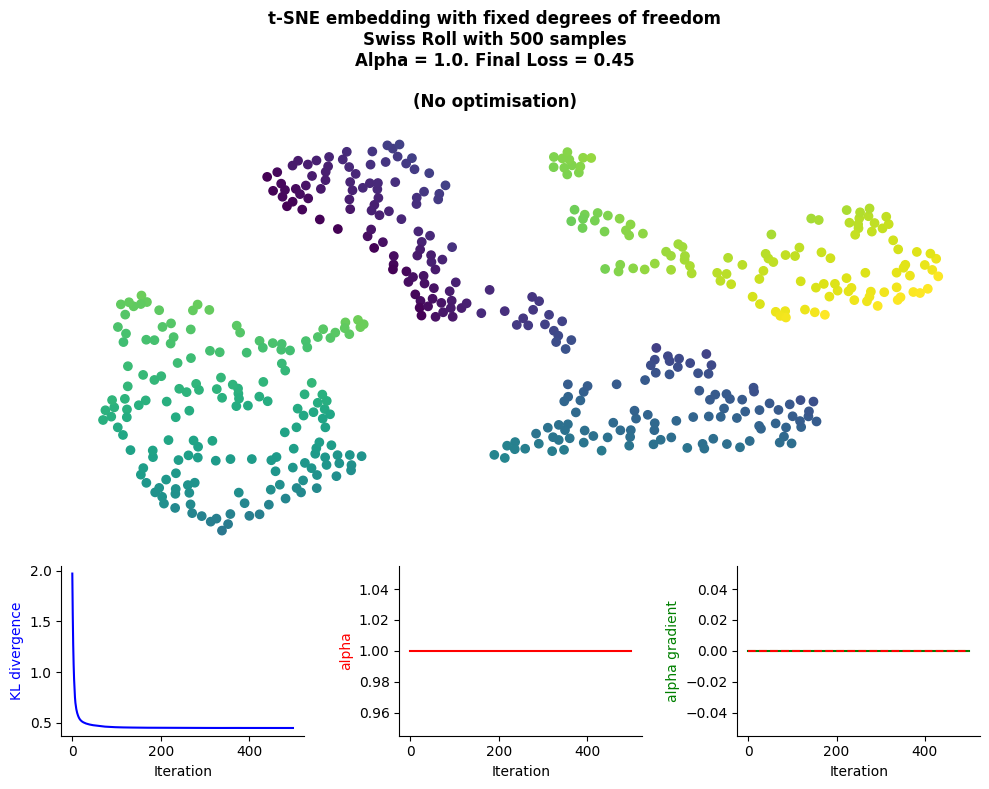

In [20]:
utils.plot_tsne_result(data=tsne_result_1_no_opt, labels=colors, additional_title='(No optimisation)')

In [21]:
tsne_result_1_gd = utils.tsne_with_dof_optimisation(
    X=X,
    n_iter=500,
    initial_alpha=test_alpha,
    dataset_name="Swiss Roll",
    verbose=True,
    optimise_for_alpha="exact",
    alpha_lr=0.5
)

Initializing the t-SNE embedding...
Computing the affinity matrix...
Performing the PCA initialization...
Initializing the t-SNE embedding...
Performing the early exaggeration fase with exaggeration = 12 and learning rate = 41.666666666666664 for 250 iterations...
Running optimization for 500 iterations...
Computing the exact gradients...
Iteration 0 out of 500 done
Current KL divergence: 1.9517357144552907
Current alpha: 1.052554447780203
Current alpha gradient: -0.1051088955604059
-----------------------------------
Iteration 1 out of 500 done
Current KL divergence: 1.475117828837286
Current alpha: 1.1807337777547742
Current alpha gradient: -0.2563586599491425
-----------------------------------
Iteration 2 out of 500 done
Current KL divergence: 1.0792442107328881
Current alpha: 1.3617544071294065
Current alpha gradient: -0.3620412587492646
-----------------------------------
Iteration 3 out of 500 done
Current KL divergence: 0.8111480032211649
Current alpha: 1.5325049975000256
Curre

In [22]:
optimal_alpha = tsne_result_1_gd.im_alphas[-1]

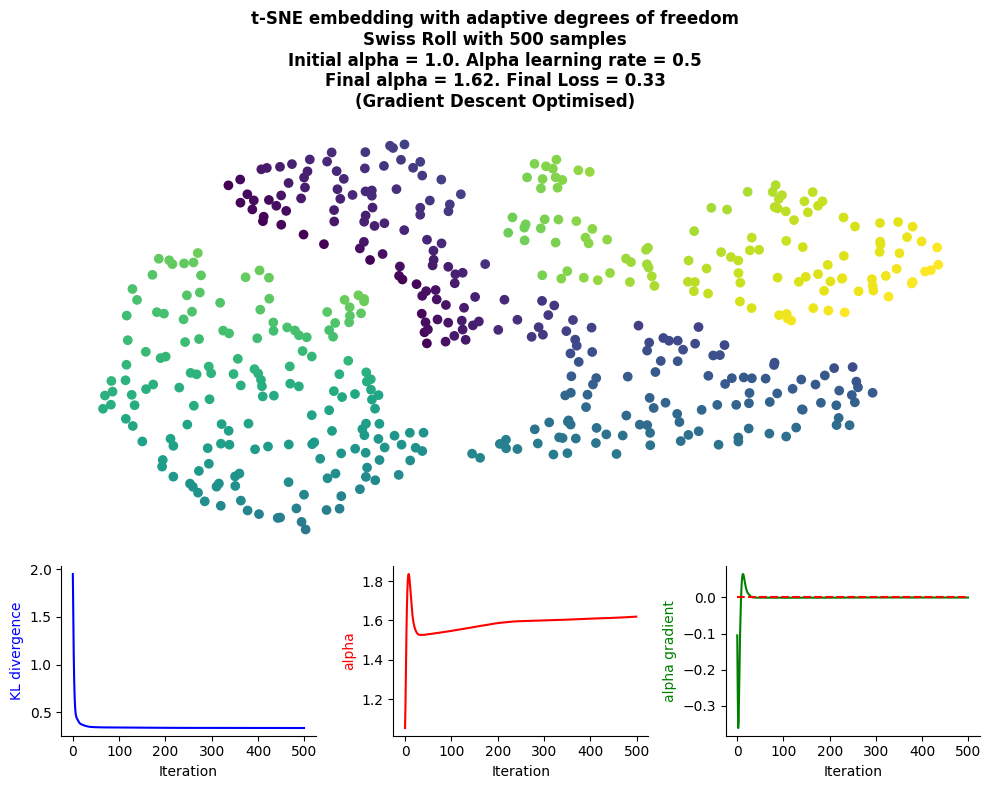

In [23]:
utils.plot_tsne_result(data=tsne_result_1_gd, labels=colors, additional_title="(Gradient Descent Optimised)")

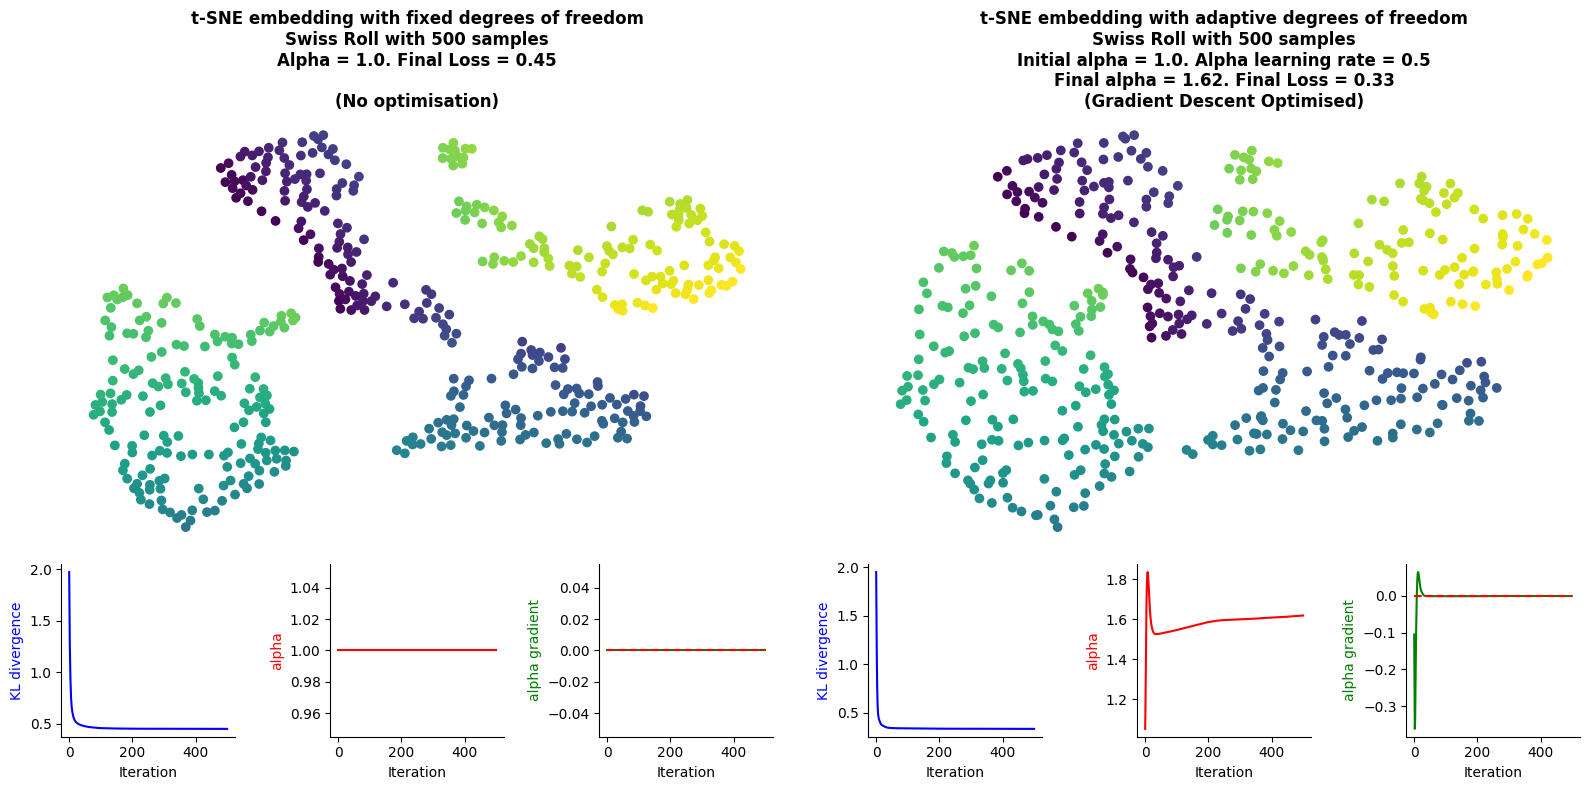

In [24]:
importlib.reload(utils)
utils.plot_side_by_side(tsne_result_1_no_opt, tsne_result_1_gd, colors, additional_title_1="(No optimisation)", additional_title_2="(Gradient Descent Optimised)")

Initializing the t-SNE embedding...
Computing the affinity matrix...
Performing the PCA initialization...
Initializing the t-SNE embedding...
Performing the early exaggeration fase with exaggeration = 12 and learning rate = 41.666666666666664 for 250 iterations...
Running optimization for 500 iterations...
Using fixed alpha...
Iteration 0 out of 500 done
Current KL divergence: 1.7672377591184638
Current alpha: 1.619123866200586
Current alpha gradient: 0.0
-----------------------------------
Iteration 1 out of 500 done
Current KL divergence: 1.2978826293923547
Current alpha: 1.619123866200586
Current alpha gradient: 0.0
-----------------------------------
Iteration 2 out of 500 done
Current KL divergence: 0.9933503709514024
Current alpha: 1.619123866200586
Current alpha gradient: 0.0
-----------------------------------
Iteration 3 out of 500 done
Current KL divergence: 0.7899270490687158
Current alpha: 1.619123866200586
Current alpha gradient: 0.0
-----------------------------------
Ite

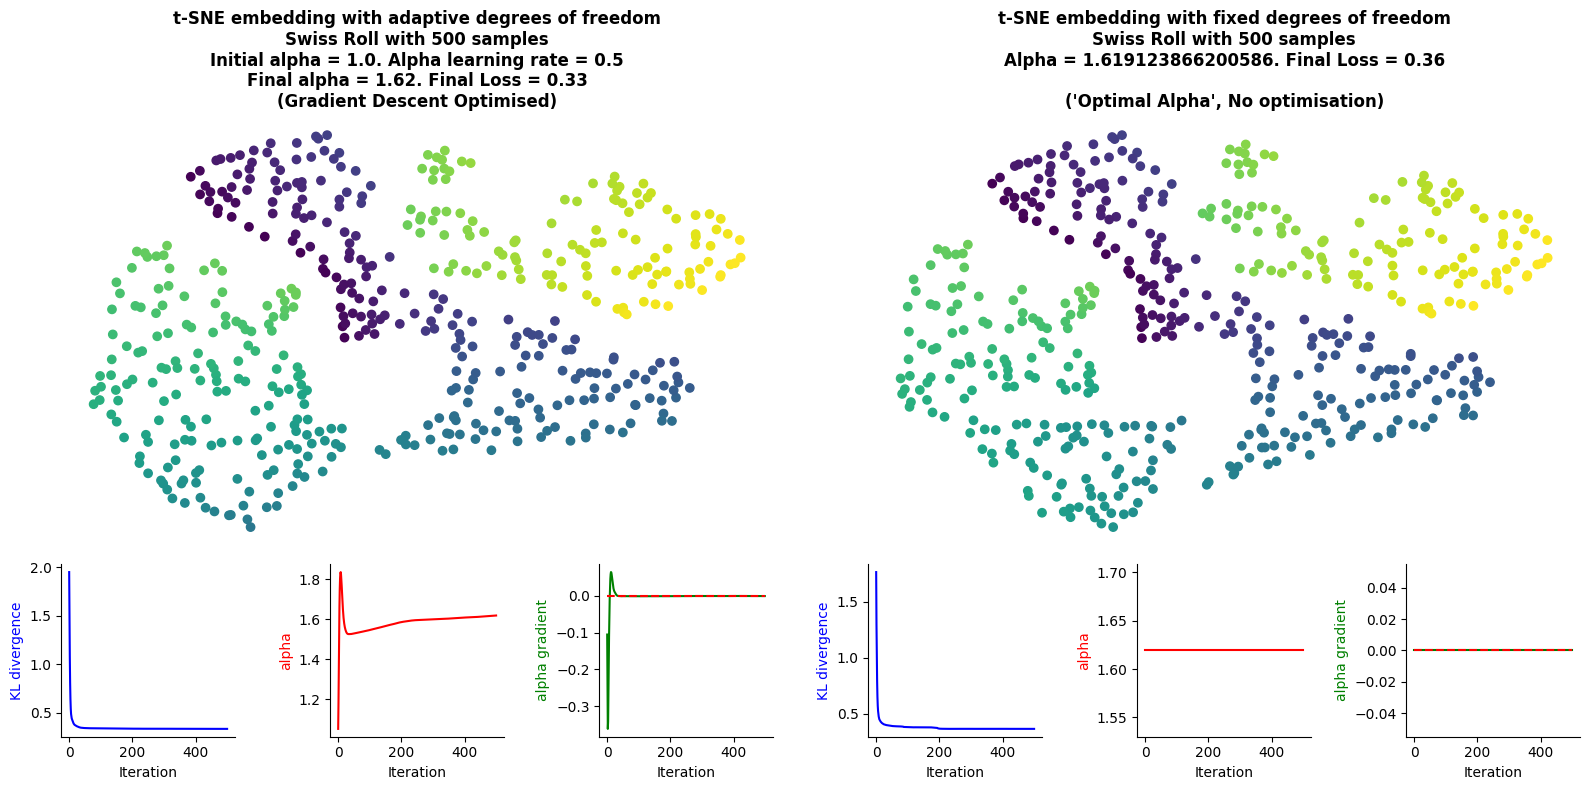

In [25]:
tsne_result_optalpha_no_opt = utils.tsne_with_dof_optimisation(X = X, n_iter = 500, initial_alpha=optimal_alpha, dataset_name='Swiss Roll', verbose=True)
utils.plot_side_by_side(tsne_result_1_gd, tsne_result_optalpha_no_opt, colors, additional_title_1="(Gradient Descent Optimised)", additional_title_2="('Optimal Alpha', No optimisation)")

In [26]:
tsne_result_1_jax = utils.tsne_with_dof_optimisation(X=X, n_iter=500, initial_alpha=test_alpha, dataset_name="Swiss Roll", verbose=True, optimise_for_alpha="jax", alpha_lr=0.5)

Initializing the t-SNE embedding...
Computing the affinity matrix...
Performing the PCA initialization...
Initializing the t-SNE embedding...
Performing the early exaggeration fase with exaggeration = 12 and learning rate = 41.666666666666664 for 250 iterations...
Running optimization for 500 iterations...
Computing the gradients using JAX...
Iteration 0 out of 500 done
Current KL divergence: 1.9516736255173264
Current alpha: 1.0527243614196777
Current alpha gradient: -0.10544869303703308
-----------------------------------
Iteration 1 out of 500 done
Current KL divergence: 1.4747429480847458
Current alpha: 1.1815721988677979
Current alpha gradient: -0.25769561529159546
-----------------------------------
Iteration 2 out of 500 done
Current KL divergence: 1.078207642176837
Current alpha: 1.364363670349121
Current alpha gradient: -0.3655828833580017
-----------------------------------
Iteration 3 out of 500 done
Current KL divergence: 0.8094135476103173
Current alpha: 1.5383273363113403

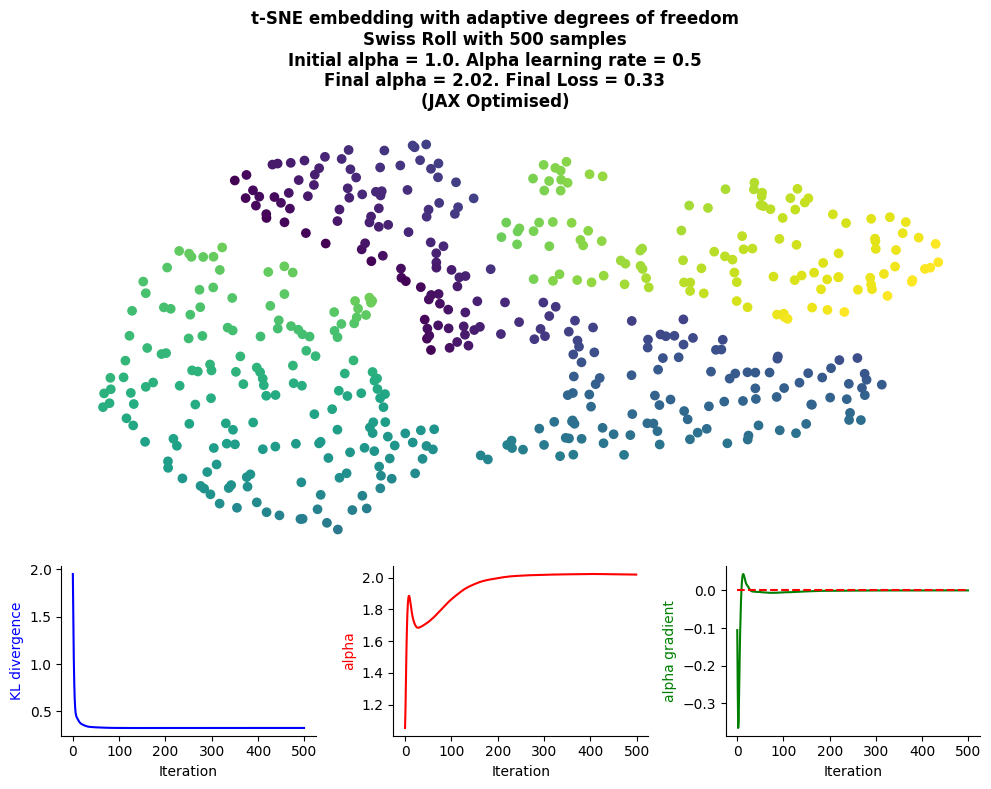

In [27]:
utils.plot_tsne_result(data=tsne_result_1_jax, labels=colors, additional_title="(JAX Optimised)")

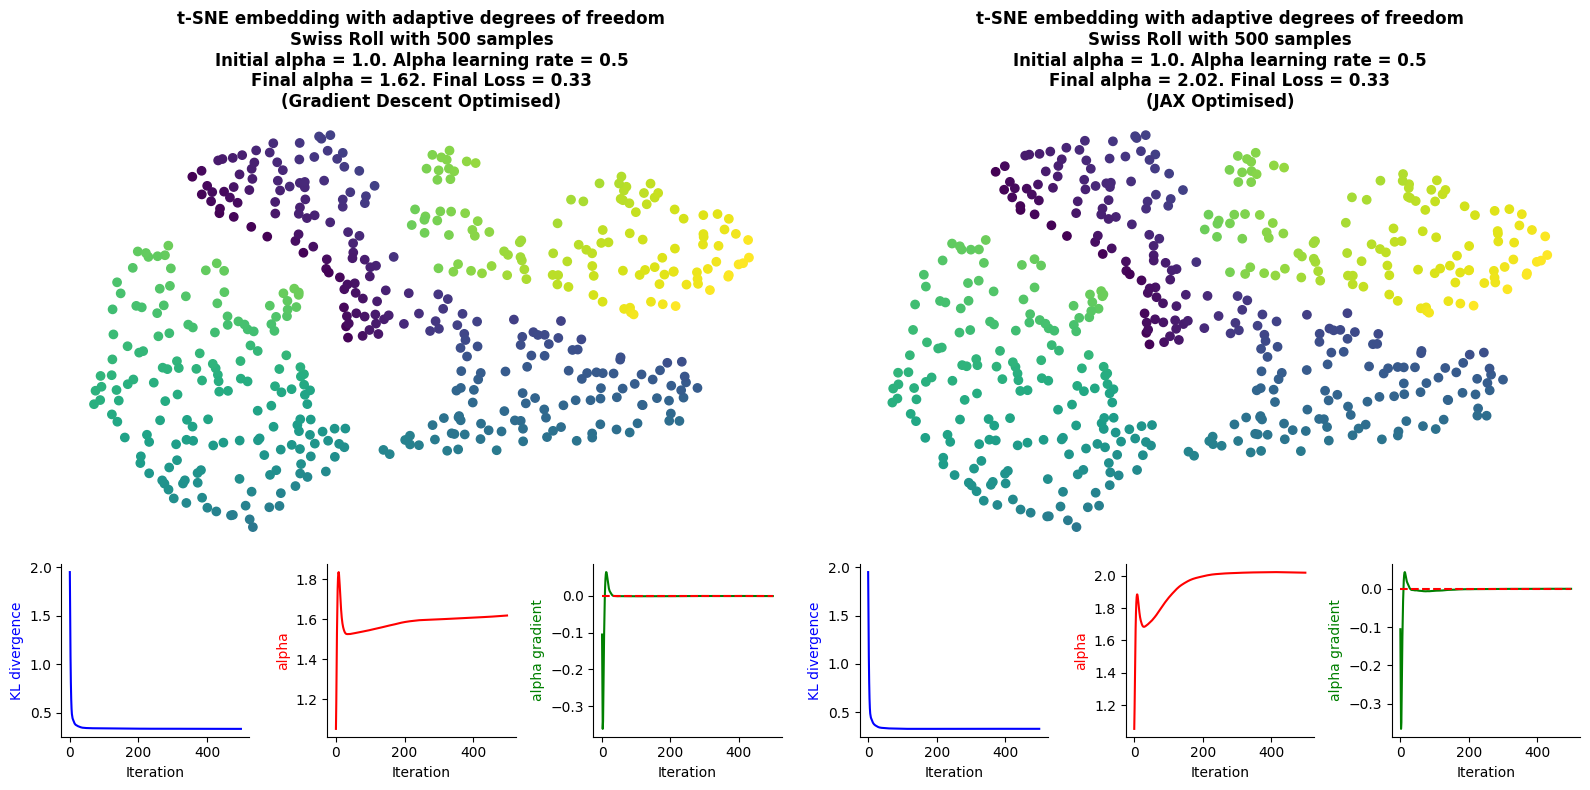

In [28]:
utils.plot_side_by_side(tsne_result_1_gd, tsne_result_1_jax, colors, additional_title_1="(Gradient Descent Optimised)", additional_title_2="(JAX Optimised)")

### Initial alpha = 5

In [29]:
test_alpha = float(5)

Initializing the t-SNE embedding...
Computing the affinity matrix...
Performing the PCA initialization...
Initializing the t-SNE embedding...
Performing the early exaggeration fase with exaggeration = 12 and learning rate = 41.666666666666664 for 250 iterations...
Running optimization for 500 iterations...
Using fixed alpha...
Initializing the t-SNE embedding...
Computing the affinity matrix...
Performing the PCA initialization...
Initializing the t-SNE embedding...
Performing the early exaggeration fase with exaggeration = 12 and learning rate = 41.666666666666664 for 250 iterations...
Running optimization for 500 iterations...
Computing the exact gradients...
Initializing the t-SNE embedding...
Computing the affinity matrix...
Performing the PCA initialization...
Initializing the t-SNE embedding...
Performing the early exaggeration fase with exaggeration = 12 and learning rate = 41.666666666666664 for 250 iterations...
Running optimization for 500 iterations...
Using fixed alpha...
I

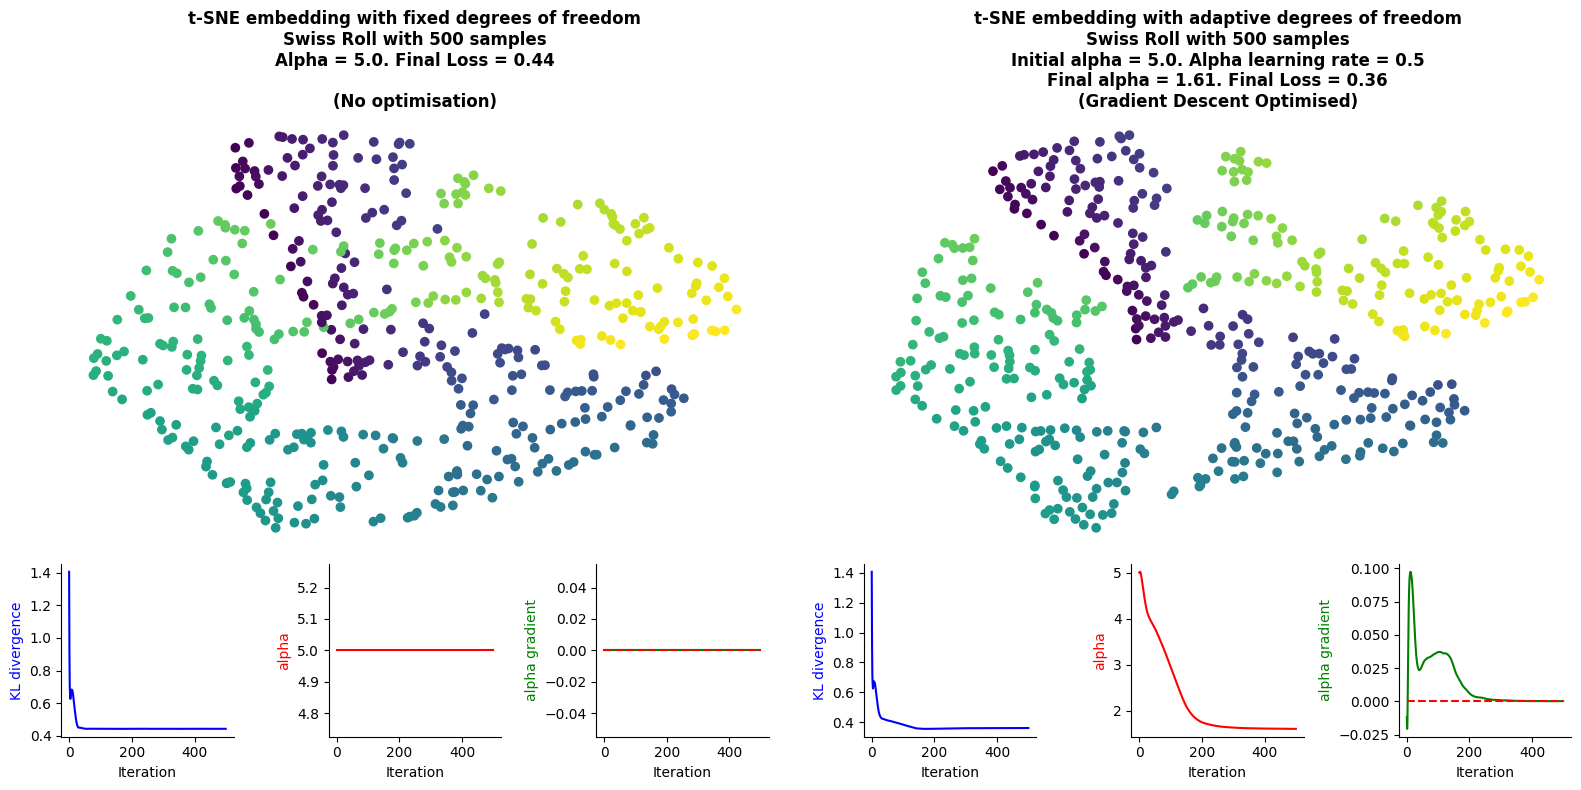

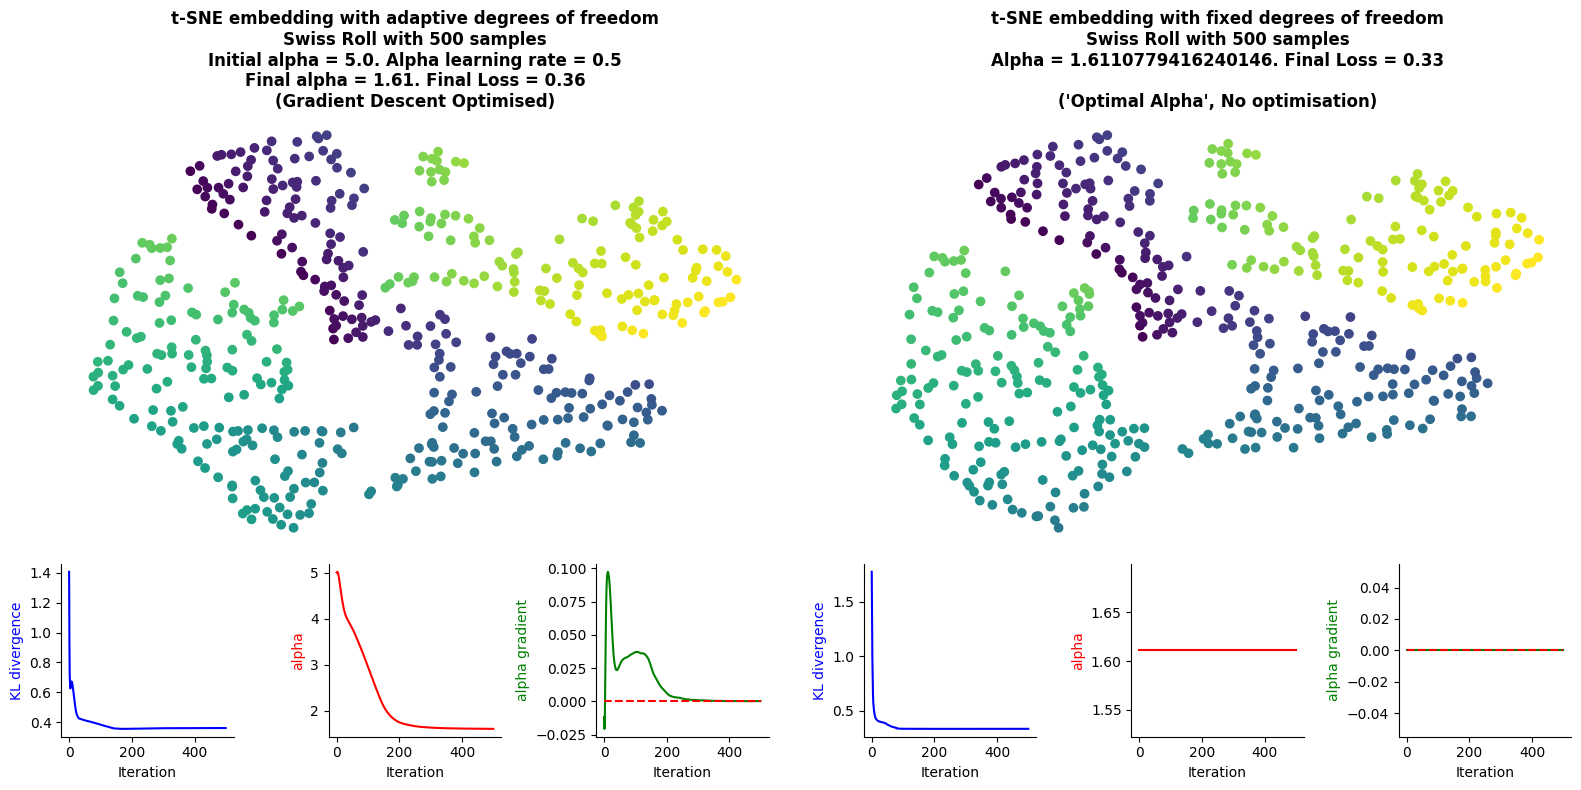

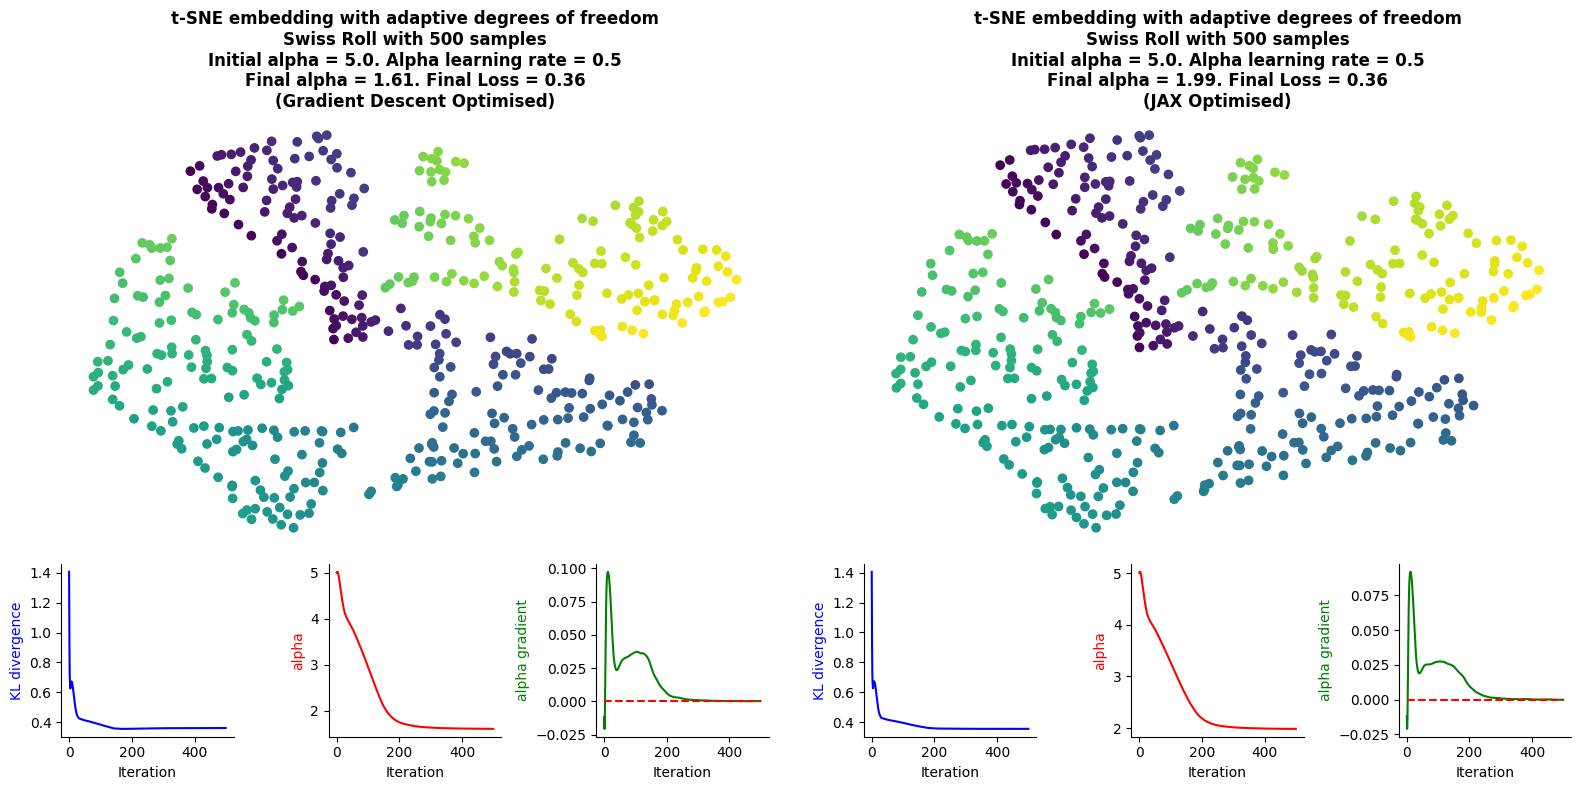

In [30]:
# run t-SNE with no optimisation
tsne_result_5_no_opt = utils.tsne_with_dof_optimisation(
    X=X, n_iter=500, initial_alpha=test_alpha, dataset_name="Swiss Roll", verbose=False
)

# run t-SNE with gradient descent optimisation
tsne_result_5_gd = utils.tsne_with_dof_optimisation(X=X, n_iter=500, initial_alpha=test_alpha, dataset_name="Swiss Roll", verbose=False, optimise_for_alpha="exact", alpha_lr=0.5)

# optimal alpha
optimal_alpha = tsne_result_5_gd.im_alphas[-1]

# run t-SNE with optimal alpha and no optimisation
tsne_result_optalpha_no_opt = utils.tsne_with_dof_optimisation(X=X, n_iter=500, initial_alpha=optimal_alpha, dataset_name="Swiss Roll", verbose=False)

# run t-SNE with JAX optimisation
tsne_result_5_jax = utils.tsne_with_dof_optimisation(X=X, n_iter=500, initial_alpha=test_alpha, dataset_name="Swiss Roll", verbose=False, optimise_for_alpha="jax", alpha_lr=0.5)

# compare t-SNE with and without optimisation
utils.plot_side_by_side(tsne_result_5_no_opt, tsne_result_5_gd, colors, additional_title_1="(No optimisation)", additional_title_2="(Gradient Descent Optimised)")

# compare t-SNE with gradient descent and no optimisation with optimal alpha
utils.plot_side_by_side(tsne_result_5_gd, tsne_result_optalpha_no_opt, colors, additional_title_1="(Gradient Descent Optimised)", additional_title_2="('Optimal Alpha', No optimisation)")

# compare t-SNE with gradient descent and JAX optimisation
utils.plot_side_by_side(tsne_result_5_gd, tsne_result_5_jax, colors, additional_title_1="(Gradient Descent Optimised)", additional_title_2="(JAX Optimised)")


### Initial Alpha = 10

In [31]:
test_alpha = float(10)

Initializing the t-SNE embedding...
Computing the affinity matrix...
Performing the PCA initialization...
Initializing the t-SNE embedding...
Performing the early exaggeration fase with exaggeration = 12 and learning rate = 41.666666666666664 for 250 iterations...
Running optimization for 2000 iterations...
Using fixed alpha...
Initializing the t-SNE embedding...
Computing the affinity matrix...
Performing the PCA initialization...
Initializing the t-SNE embedding...
Performing the early exaggeration fase with exaggeration = 12 and learning rate = 41.666666666666664 for 250 iterations...
Running optimization for 2000 iterations...
Computing the exact gradients...
Initializing the t-SNE embedding...
Computing the affinity matrix...
Performing the PCA initialization...
Initializing the t-SNE embedding...
Performing the early exaggeration fase with exaggeration = 12 and learning rate = 41.666666666666664 for 250 iterations...
Running optimization for 2000 iterations...
Using fixed alpha..

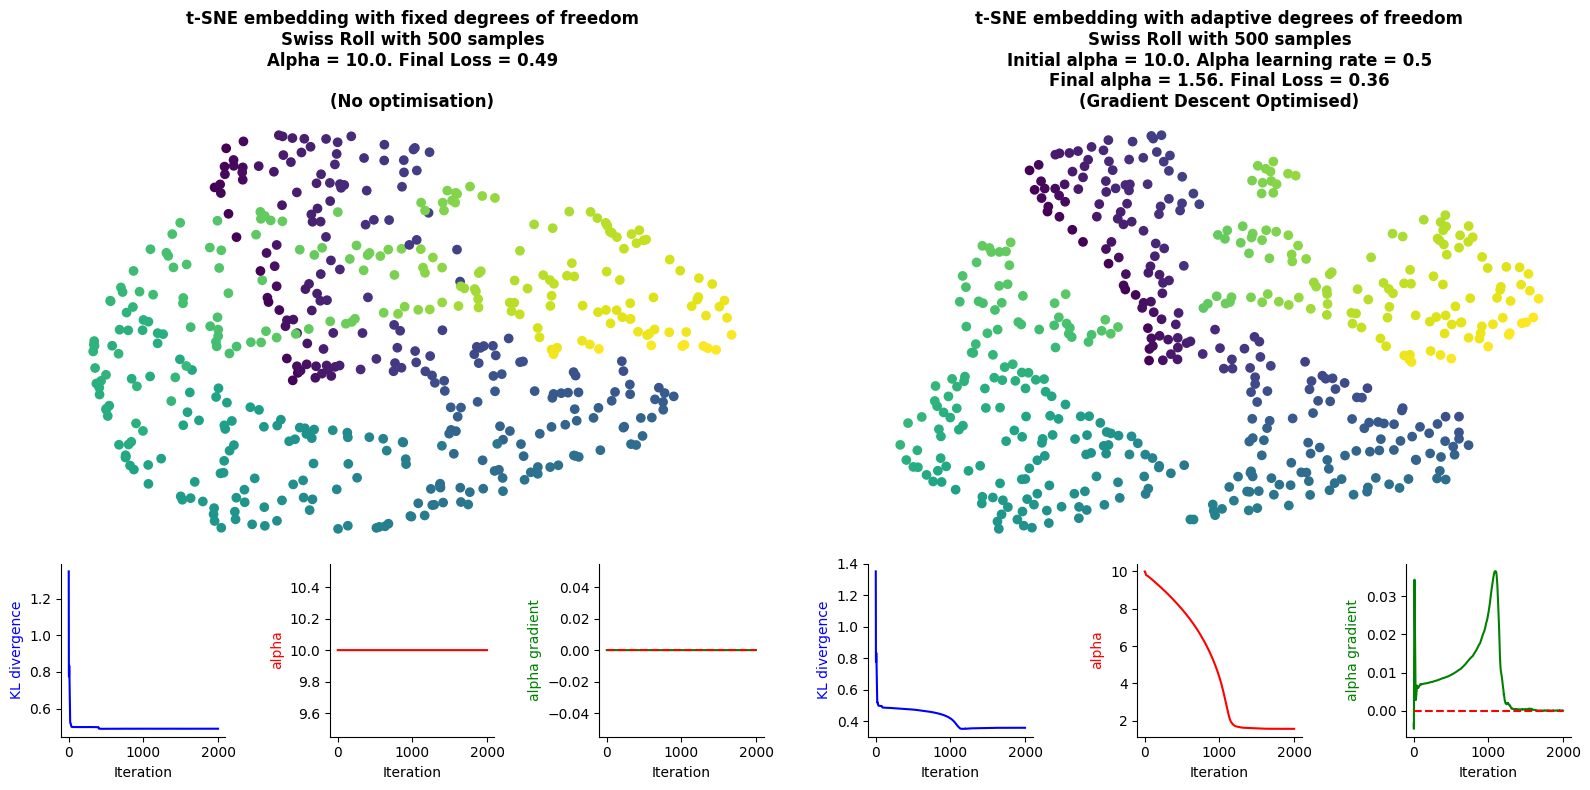

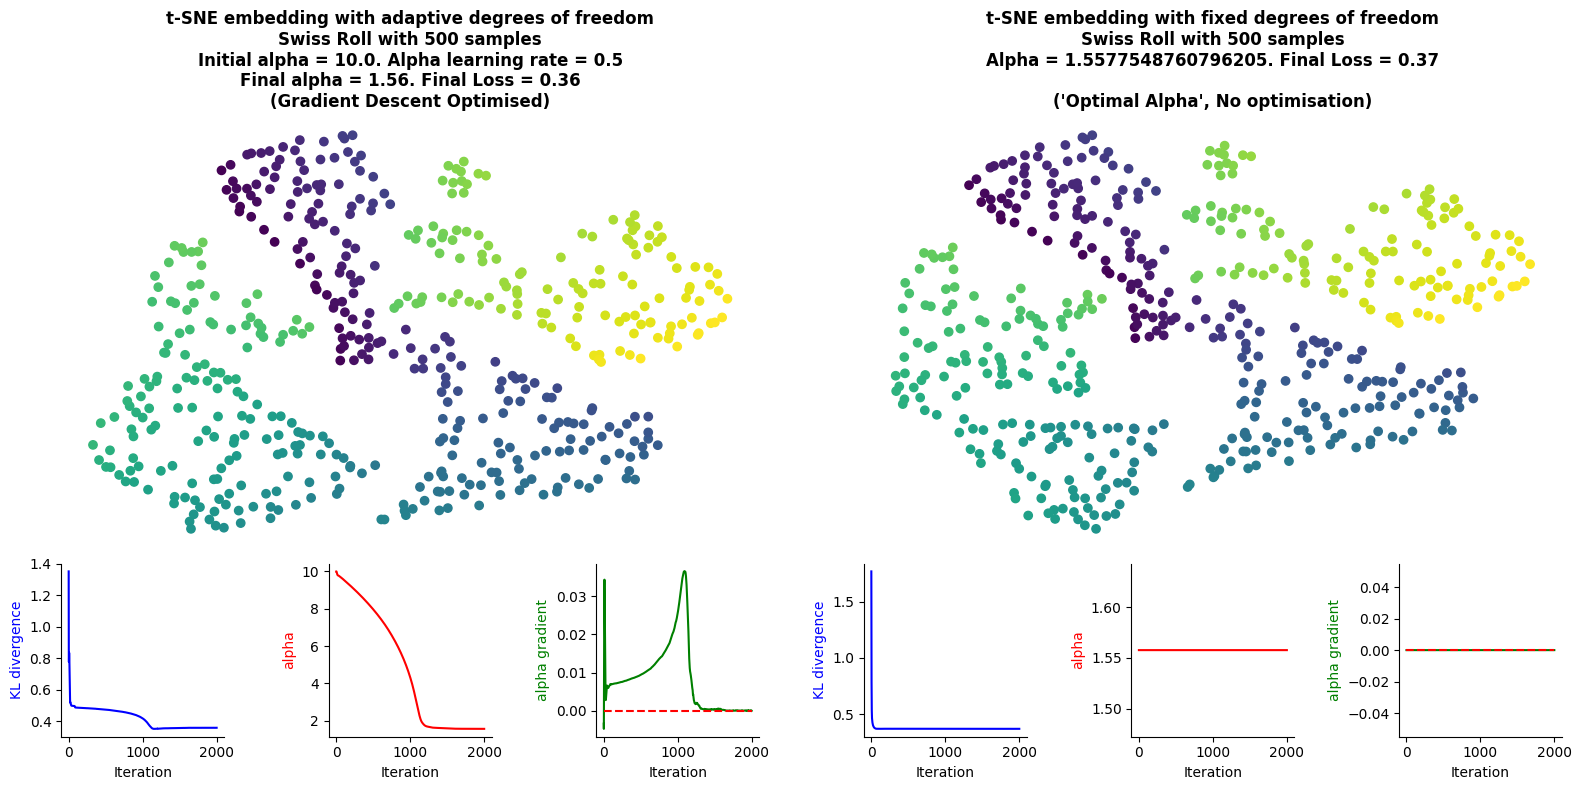

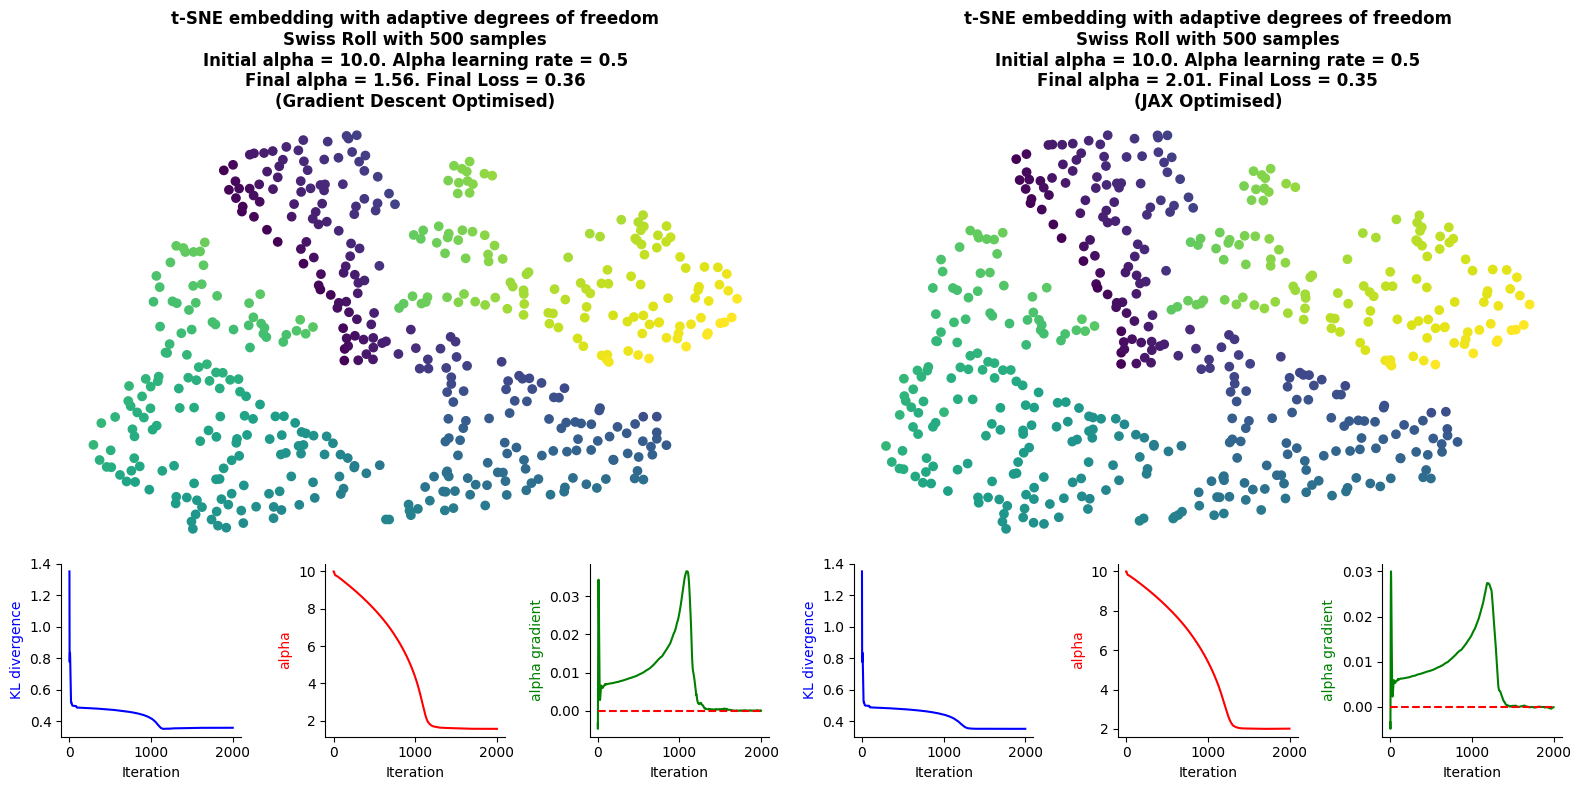

In [32]:
# here we have to run the t-SNE with more iterations for alpha to converge

# run t-SNE with no optimisation
tsne_result_10_no_opt = utils.tsne_with_dof_optimisation(
    X=X, n_iter=2000, initial_alpha=test_alpha, dataset_name="Swiss Roll", verbose=False
)

# run t-SNE with gradient descent optimisation
tsne_result_10_gd = utils.tsne_with_dof_optimisation(X=X, n_iter=2000, initial_alpha=test_alpha, dataset_name="Swiss Roll", verbose=False, optimise_for_alpha="exact", alpha_lr=0.5)

# optimal alpha
optimal_alpha = tsne_result_10_gd.im_alphas[-1]

# run t-SNE with optimal alpha and no optimisation
tsne_result_optalpha_no_opt = utils.tsne_with_dof_optimisation(X=X, n_iter=2000, initial_alpha=optimal_alpha, dataset_name="Swiss Roll", verbose=False)

# run t-SNE with JAX optimisation
tsne_result_10_jax = utils.tsne_with_dof_optimisation(X=X, n_iter=2000, initial_alpha=test_alpha, dataset_name="Swiss Roll", verbose=False, optimise_for_alpha="jax", alpha_lr=0.5)

# compare t-SNE with and without optimisation
utils.plot_side_by_side(tsne_result_10_no_opt, tsne_result_10_gd, colors, additional_title_1="(No optimisation)", additional_title_2="(Gradient Descent Optimised)")

# compare t-SNE with gradient descent and no optimisation with optimal alpha
utils.plot_side_by_side(tsne_result_10_gd, tsne_result_optalpha_no_opt, colors, additional_title_1="(Gradient Descent Optimised)", additional_title_2="('Optimal Alpha', No optimisation)")

# compare t-SNE with gradient descent and JAX optimisation
utils.plot_side_by_side(tsne_result_10_gd, tsne_result_10_jax, colors, additional_title_1="(Gradient Descent Optimised)", additional_title_2="(JAX Optimised)")

#### Initial alpha = 0.5

In [33]:
X, colors = make_swiss_roll(n_samples=500, noise=0, random_state=42)


In [34]:
test_alpha = float(0.5)

Initializing the t-SNE embedding...
Computing the affinity matrix...
Performing the PCA initialization...
Initializing the t-SNE embedding...
Performing the early exaggeration fase with exaggeration = 12 and learning rate = 41.666666666666664 for 250 iterations...
Running optimization for 500 iterations...
Using fixed alpha...
Initializing the t-SNE embedding...
Computing the affinity matrix...
Performing the PCA initialization...
Initializing the t-SNE embedding...
Performing the early exaggeration fase with exaggeration = 12 and learning rate = 41.666666666666664 for 250 iterations...
Running optimization for 500 iterations...
Computing the exact gradients...
Initializing the t-SNE embedding...
Computing the affinity matrix...
Performing the PCA initialization...
Initializing the t-SNE embedding...
Performing the early exaggeration fase with exaggeration = 12 and learning rate = 41.666666666666664 for 250 iterations...
Running optimization for 500 iterations...
Using fixed alpha...
I

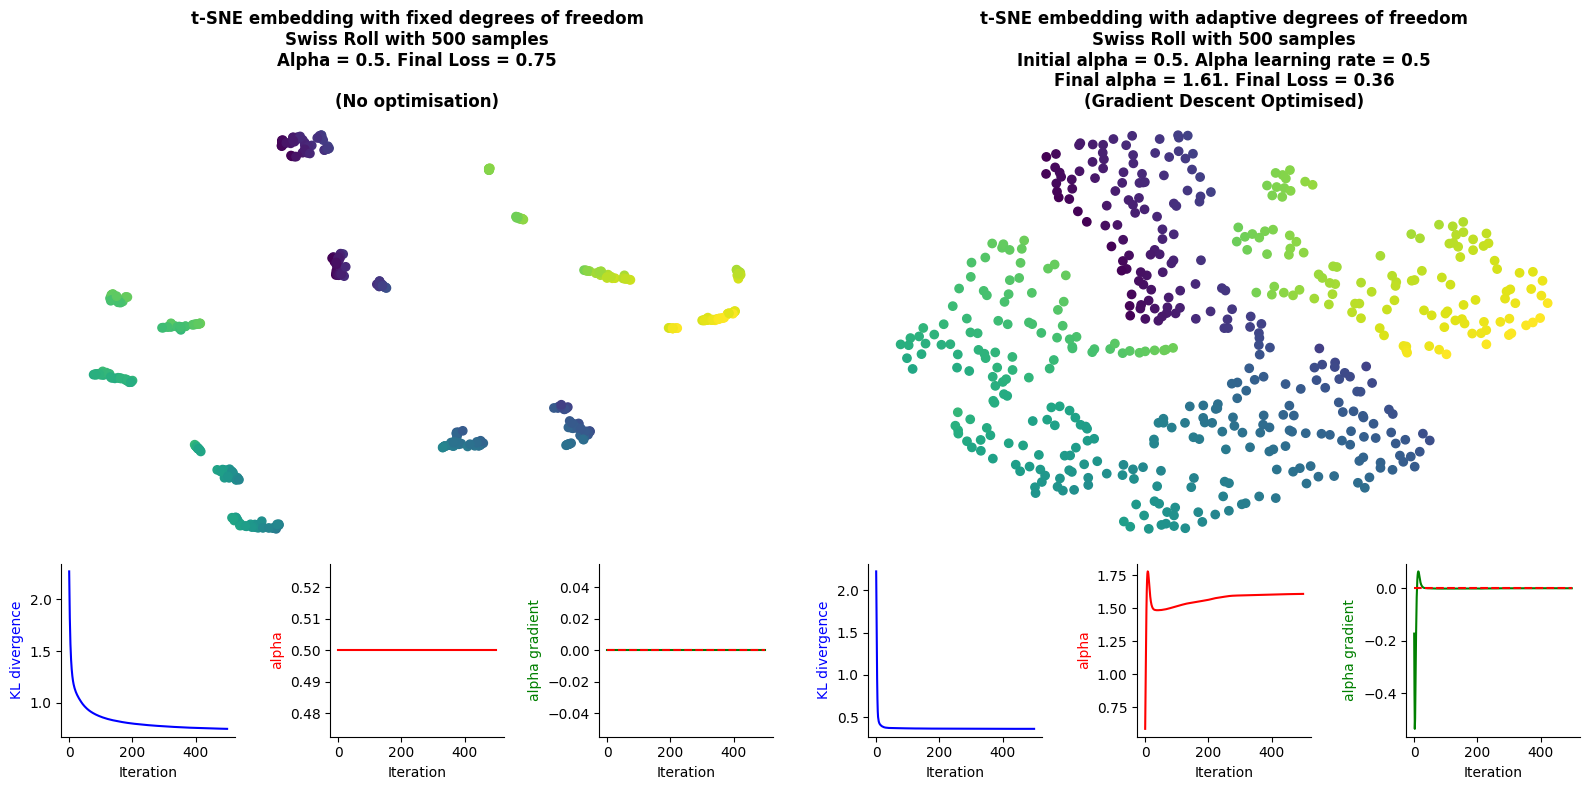

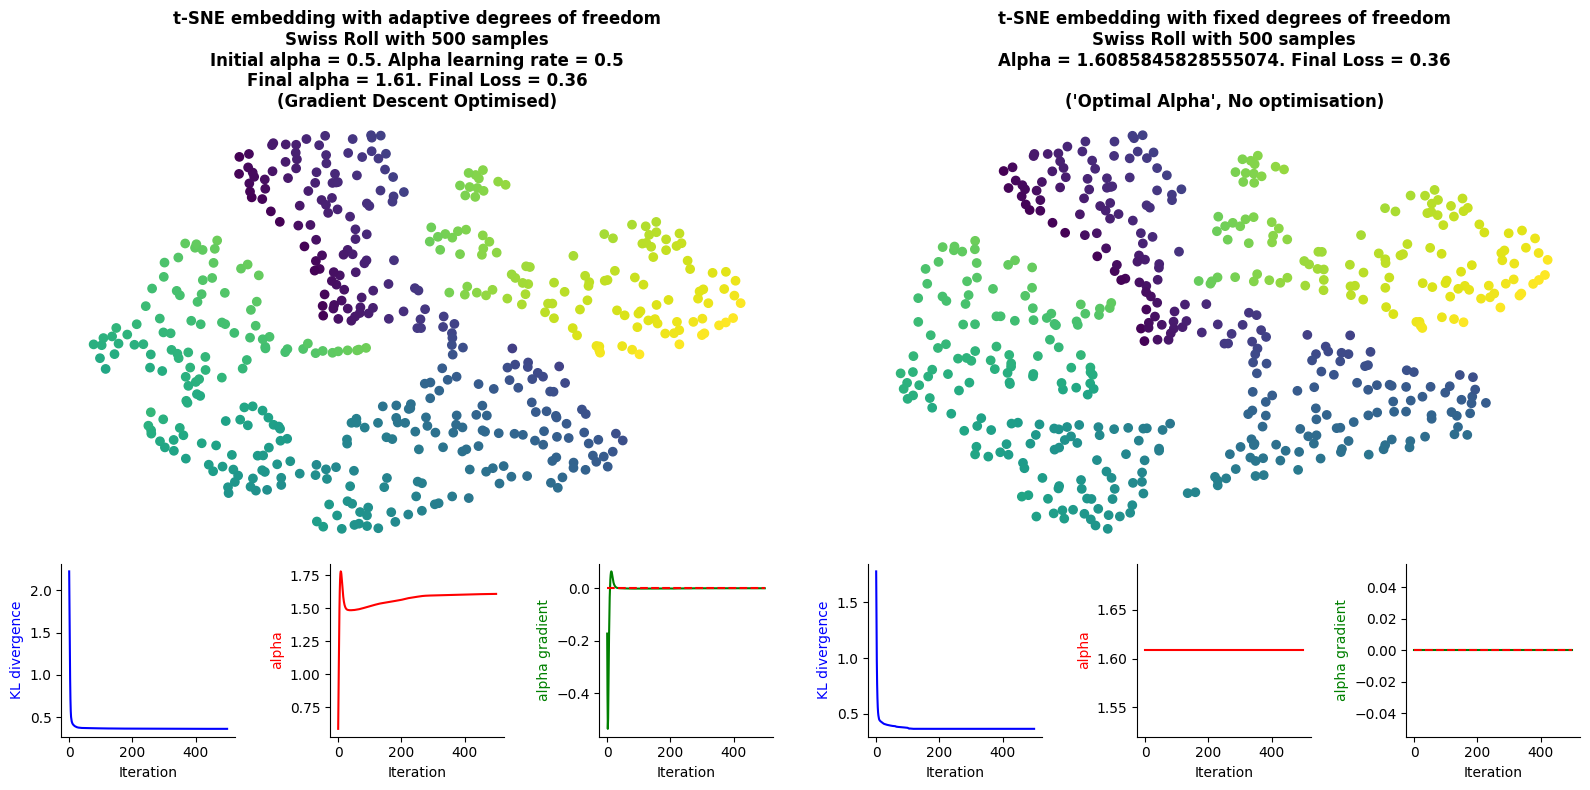

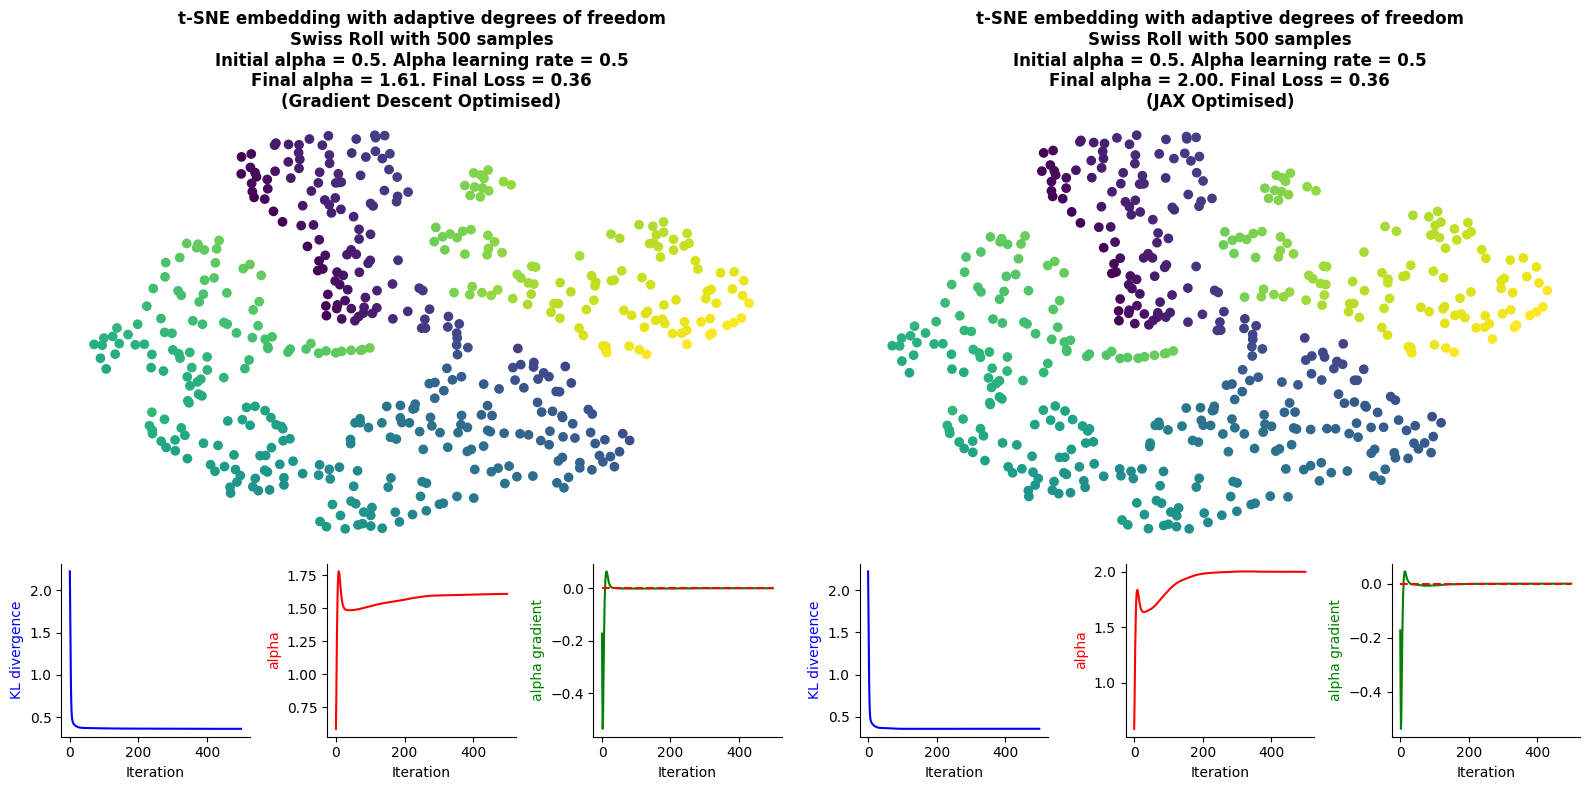

In [35]:
# run t-SNE with no optimisation
tsne_result_10_no_opt = utils.tsne_with_dof_optimisation(
    X=X, n_iter=500, initial_alpha=test_alpha, dataset_name="Swiss Roll", verbose=False
)

# run t-SNE with gradient descent optimisation
tsne_result_10_gd = utils.tsne_with_dof_optimisation(X=X, n_iter=500, initial_alpha=test_alpha, dataset_name="Swiss Roll", verbose=False, optimise_for_alpha="exact", alpha_lr=0.5)

# optimal alpha
optimal_alpha = tsne_result_10_gd.im_alphas[-1]

# run t-SNE with optimal alpha and no optimisation
tsne_result_optalpha_no_opt = utils.tsne_with_dof_optimisation(X=X, n_iter=500, initial_alpha=optimal_alpha, dataset_name="Swiss Roll", verbose=False)

# run t-SNE with JAX optimisation
tsne_result_10_jax = utils.tsne_with_dof_optimisation(X=X, n_iter=500, initial_alpha=test_alpha, dataset_name="Swiss Roll", verbose=False, optimise_for_alpha="jax", alpha_lr=0.5)

# compare t-SNE with and without optimisation
utils.plot_side_by_side(tsne_result_10_no_opt, tsne_result_10_gd, colors, additional_title_1="(No optimisation)", additional_title_2="(Gradient Descent Optimised)")

# compare t-SNE with gradient descent and no optimisation with optimal alpha
utils.plot_side_by_side(tsne_result_10_gd, tsne_result_optalpha_no_opt, colors, additional_title_1="(Gradient Descent Optimised)", additional_title_2="('Optimal Alpha', No optimisation)")

# compare t-SNE with gradient descent and JAX optimisation
utils.plot_side_by_side(tsne_result_10_gd, tsne_result_10_jax, colors, additional_title_1="(Gradient Descent Optimised)", additional_title_2="(JAX Optimised)")

### Swiss Roll with 5000 datapoints

#### Initial alpha = 1

In [36]:
X, colors = make_swiss_roll(n_samples=5000, noise=0., random_state=0)

In [37]:
test_alpha = float(1)

Initializing the t-SNE embedding...
Computing the affinity matrix...
Performing the PCA initialization...
Initializing the t-SNE embedding...
Performing the early exaggeration fase with exaggeration = 12 and learning rate = 416.6666666666667 for 250 iterations...
Running optimization for 500 iterations...
Using fixed alpha...
Initializing the t-SNE embedding...
Computing the affinity matrix...
Performing the PCA initialization...
Initializing the t-SNE embedding...
Performing the early exaggeration fase with exaggeration = 12 and learning rate = 416.6666666666667 for 250 iterations...
Running optimization for 500 iterations...
Computing the exact gradients...
Initializing the t-SNE embedding...
Computing the affinity matrix...
Performing the PCA initialization...
Initializing the t-SNE embedding...
Performing the early exaggeration fase with exaggeration = 12 and learning rate = 416.6666666666667 for 250 iterations...
Running optimization for 500 iterations...
Using fixed alpha...
Init

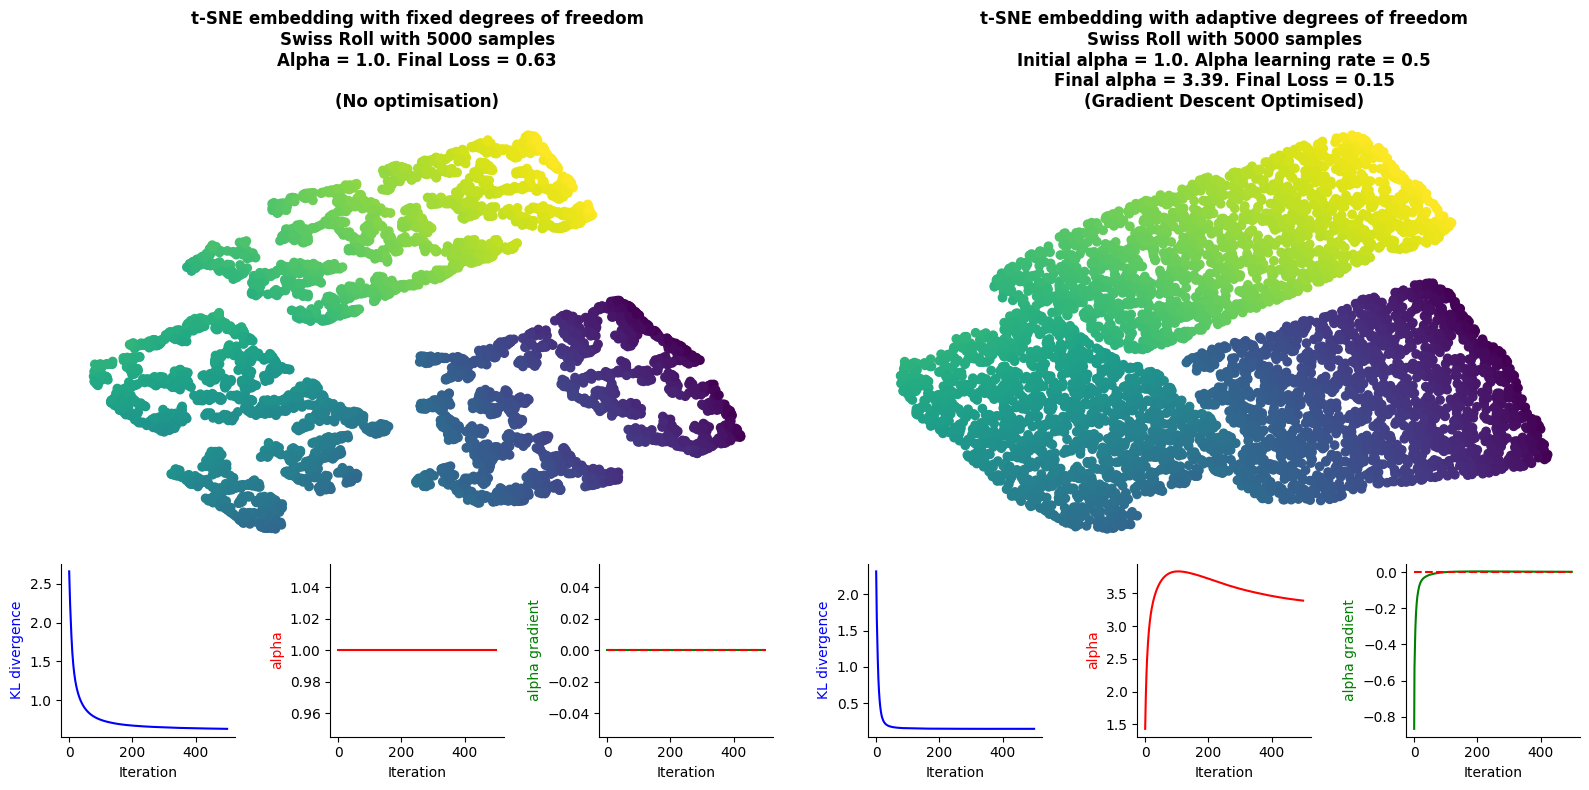

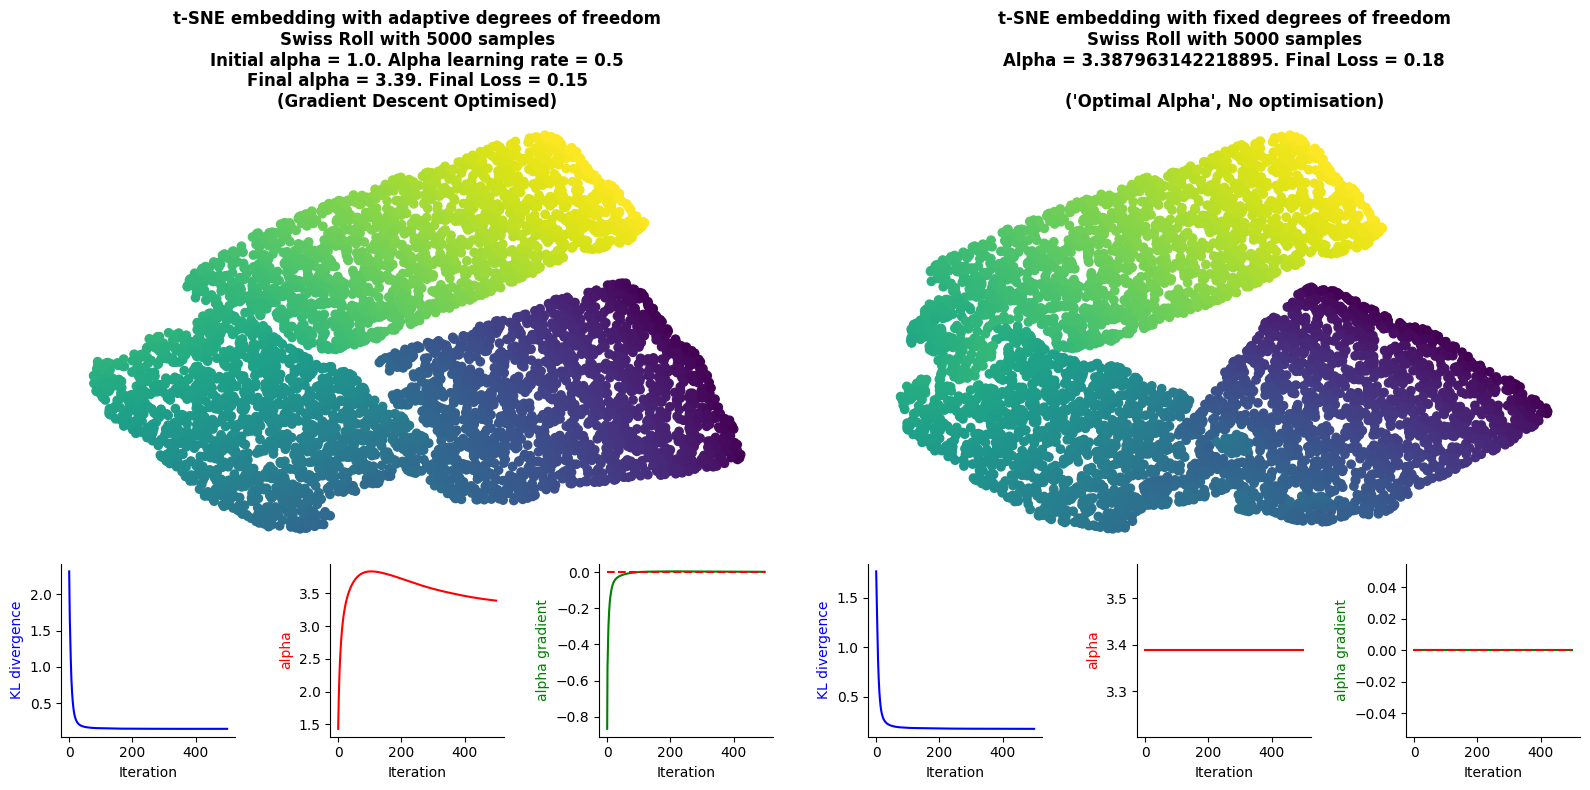

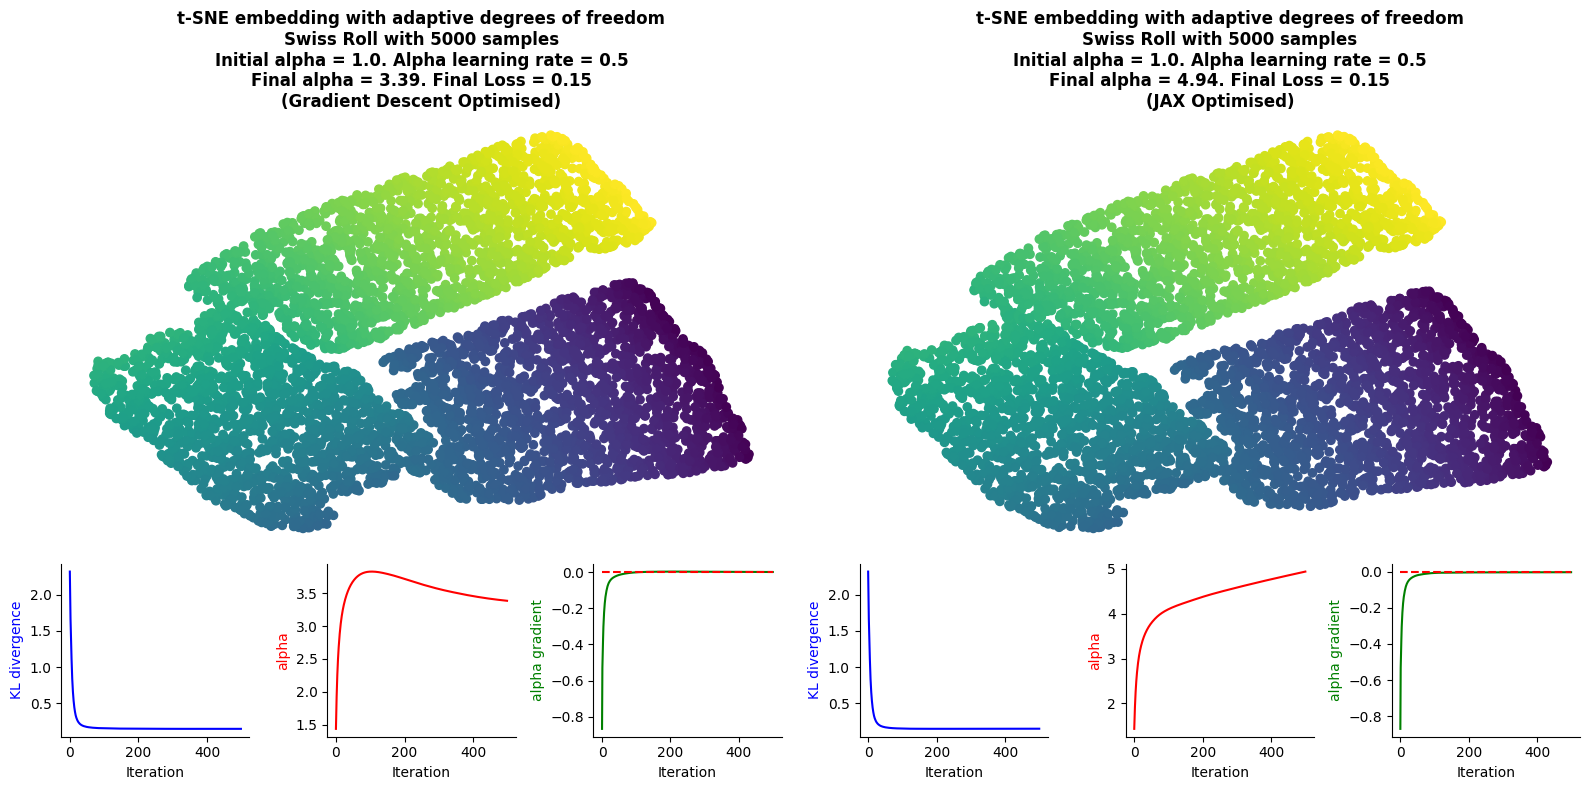

In [38]:
# run t-SNE with no optimization
tsne_result_5_no_opt = utils.tsne_with_dof_optimisation(
    X=X, n_iter=500, initial_alpha=test_alpha, dataset_name="Swiss Roll", verbose=False
)

# run t-SNE with gradient descent optimization
tsne_result_5_gd = utils.tsne_with_dof_optimisation(X=X, n_iter=500, initial_alpha=test_alpha, dataset_name="Swiss Roll", verbose=False, optimise_for_alpha="exact", alpha_lr=0.5)

# optimal alpha
optimal_alpha = tsne_result_5_gd.im_alphas[-1]

# run t-SNE with optimal alpha and no optimization
tsne_result_optalpha_no_opt = utils.tsne_with_dof_optimisation(X=X, n_iter=500, initial_alpha=optimal_alpha, dataset_name="Swiss Roll", verbose=False)

# run t-SNE with JAX optimization
tsne_result_5_jax = utils.tsne_with_dof_optimisation(X=X, n_iter=500, initial_alpha=test_alpha, dataset_name="Swiss Roll", verbose=False, optimise_for_alpha="jax", alpha_lr=0.5)

# compare t-SNE with and without optimization
utils.plot_side_by_side(tsne_result_5_no_opt, tsne_result_5_gd, colors, additional_title_1="(No optimisation)", additional_title_2="(Gradient Descent Optimised)")

# compare t-SNE with gradient descent and no optimization with optimal alpha
utils.plot_side_by_side(tsne_result_5_gd, tsne_result_optalpha_no_opt, colors, additional_title_1="(Gradient Descent Optimised)", additional_title_2="('Optimal Alpha', No optimisation)")

# compare t-SNE with gradient descent and JAX optimization
utils.plot_side_by_side(tsne_result_5_gd, tsne_result_5_jax, colors, additional_title_1="(Gradient Descent Optimised)", additional_title_2="(JAX Optimised)")


### Digits dataset

In [39]:
digits = load_digits(n_class=10)
digit_colors = sns.color_palette("Spectral", as_cmap=True)
X, color = digits.data, digits.target

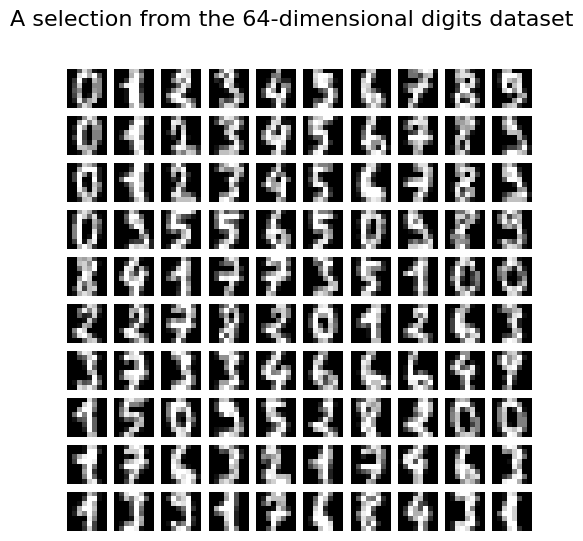

In [40]:
fig, axs = plt.subplots(nrows=10, ncols=10, figsize=(6, 6))
for idx, ax in enumerate(axs.ravel()):
    ax.imshow(X[idx].reshape((8, 8)), cmap="grey")
    ax.axis("off")
_ = fig.suptitle("A selection from the 64-dimensional digits dataset", fontsize=16)

#### Initial alpha = 1

In [41]:
test_alpha = float(1)

In [42]:
tsne_result_digits_1_no_opt = utils.tsne_with_dof_optimisation(X=X, n_iter=500, initial_alpha=test_alpha, dataset_name="Digits", verbose=True)

Initializing the t-SNE embedding...
Computing the affinity matrix...
Performing the PCA initialization...
Initializing the t-SNE embedding...
Performing the early exaggeration fase with exaggeration = 12 and learning rate = 149.75 for 250 iterations...
Running optimization for 500 iterations...
Using fixed alpha...
Iteration 0 out of 500 done
Current KL divergence: 2.452001252421768
Current alpha: 1.0
Current alpha gradient: 0.0
-----------------------------------
Iteration 1 out of 500 done
Current KL divergence: 2.256341822182648
Current alpha: 1.0
Current alpha gradient: 0.0
-----------------------------------
Iteration 2 out of 500 done
Current KL divergence: 2.0628357288792127
Current alpha: 1.0
Current alpha gradient: 0.0
-----------------------------------
Iteration 3 out of 500 done
Current KL divergence: 1.8908259524365647
Current alpha: 1.0
Current alpha gradient: 0.0
-----------------------------------
Iteration 4 out of 500 done
Current KL divergence: 1.7508768926743414
Cur

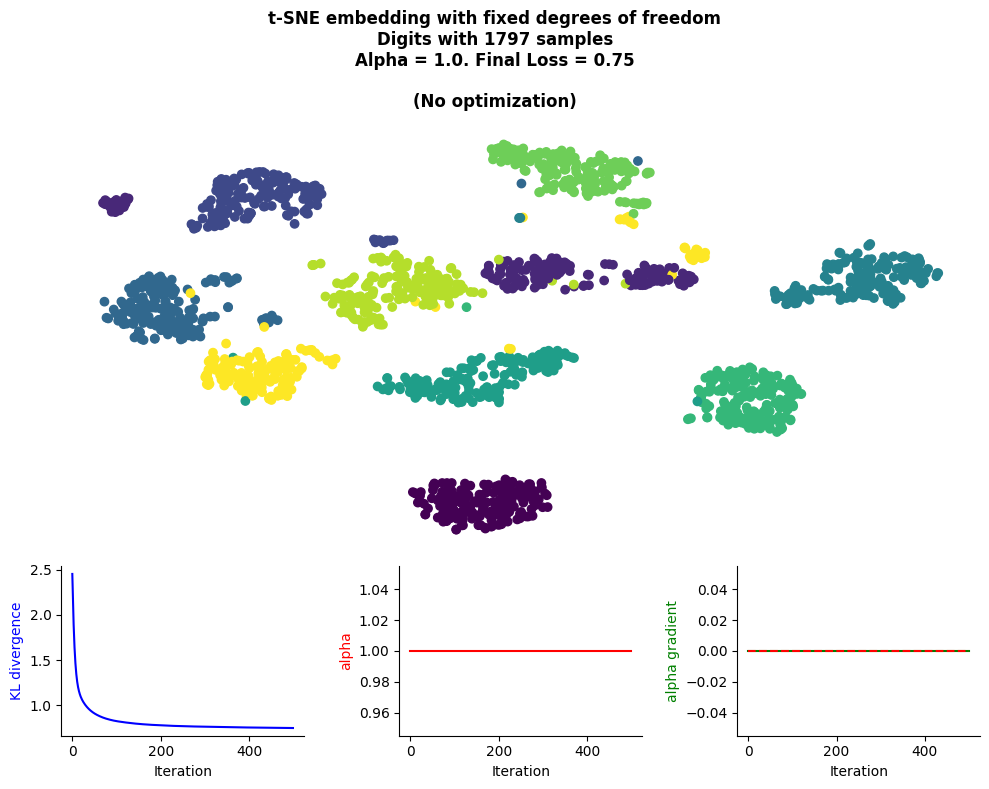

In [43]:
utils.plot_tsne_result(data=tsne_result_digits_1_no_opt, labels=color, additional_title="(No optimization)")

In [44]:
tsne_result_digits_1_gd = utils.tsne_with_dof_optimisation(X=X, n_iter=500, initial_alpha=test_alpha, dataset_name="Digits", verbose=True, optimise_for_alpha="exact", alpha_lr=0.5)

Initializing the t-SNE embedding...
Computing the affinity matrix...
Performing the PCA initialization...
Initializing the t-SNE embedding...
Performing the early exaggeration fase with exaggeration = 12 and learning rate = 149.75 for 250 iterations...
Running optimization for 500 iterations...
Computing the exact gradients...
Iteration 0 out of 500 done
Current KL divergence: 2.3456838094796506
Current alpha: 1.216341435783515
Current alpha gradient: -0.4326828715670297
-----------------------------------
Iteration 1 out of 500 done
Current KL divergence: 2.049616833566544
Current alpha: 1.4031474355618552
Current alpha gradient: -0.3736119995566806
-----------------------------------
Iteration 2 out of 500 done
Current KL divergence: 1.760511793892281
Current alpha: 1.5693559282181697
Current alpha gradient: -0.3324169853126292
-----------------------------------
Iteration 3 out of 500 done
Current KL divergence: 1.5139178813170133
Current alpha: 1.718935894378581
Current alpha gradi

In [45]:
optimal_alpha = tsne_result_digits_1_gd.im_alphas[-1]

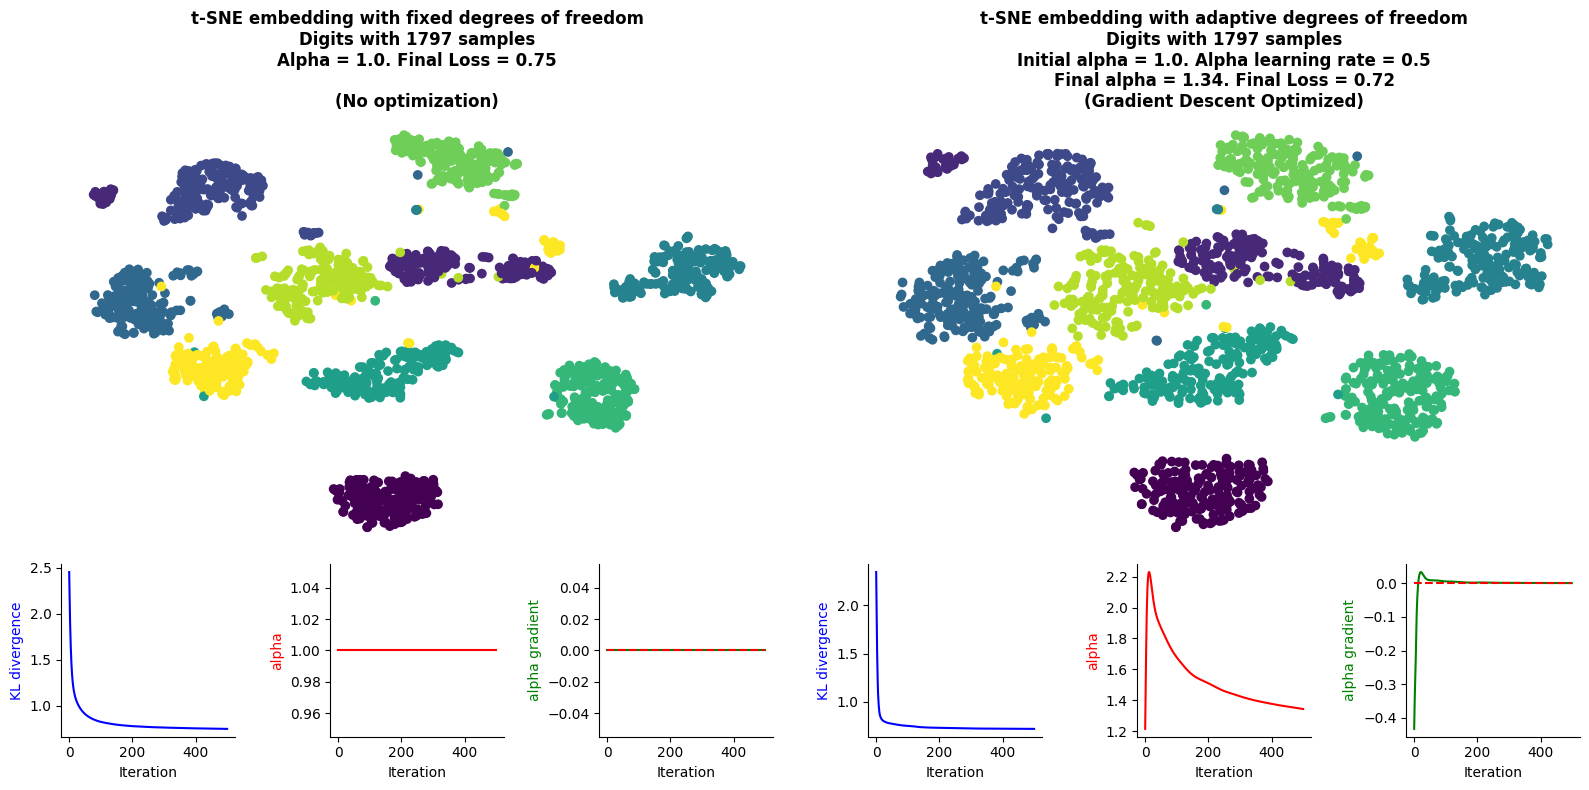

In [46]:
utils.plot_side_by_side(tsne_result_digits_1_no_opt, tsne_result_digits_1_gd, color, additional_title_1="(No optimization)", additional_title_2="(Gradient Descent Optimized)")

Initializing the t-SNE embedding...
Computing the affinity matrix...
Performing the PCA initialization...
Initializing the t-SNE embedding...
Performing the early exaggeration fase with exaggeration = 12 and learning rate = 149.75 for 250 iterations...
Running optimization for 500 iterations...
Using fixed alpha...


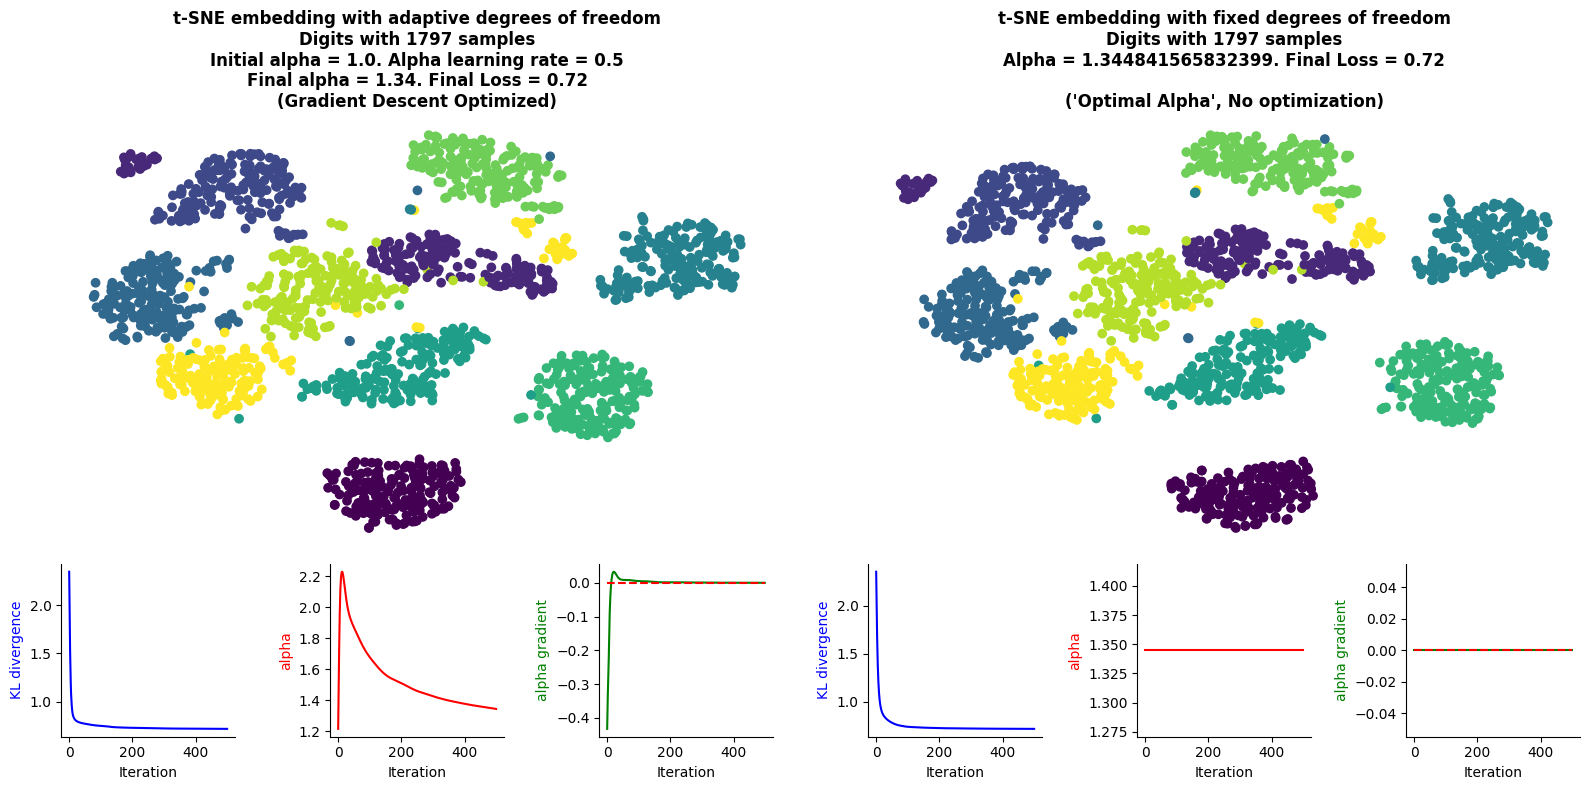

In [50]:
tsne_result_digits_optalpha_no_opt = utils.tsne_with_dof_optimisation(X=X, n_iter=500, initial_alpha=optimal_alpha, dataset_name="Digits", verbose=False)
utils.plot_side_by_side(tsne_result_digits_1_gd, tsne_result_digits_optalpha_no_opt, color, additional_title_1="(Gradient Descent Optimized)", additional_title_2="('Optimal Alpha', No optimization)")

Initializing the t-SNE embedding...
Computing the affinity matrix...
Performing the PCA initialization...
Initializing the t-SNE embedding...
Performing the early exaggeration fase with exaggeration = 12 and learning rate = 149.75 for 250 iterations...
Running optimization for 500 iterations...
Computing the gradients using JAX...
Iteration 0 out of 500 done
Current KL divergence: 2.3454549017577158
Current alpha: 1.2168773412704468
Current alpha gradient: -0.43375465273857117
-----------------------------------
Iteration 1 out of 500 done
Current KL divergence: 2.0492270887383466
Current alpha: 1.4041796922683716
Current alpha gradient: -0.3746047616004944
-----------------------------------
Iteration 2 out of 500 done
Current KL divergence: 1.759992325961404
Current alpha: 1.570997953414917
Current alpha gradient: -0.33363664150238037
-----------------------------------
Iteration 3 out of 500 done
Current KL divergence: 1.5132295180756294
Current alpha: 1.7214579582214355
Current alp

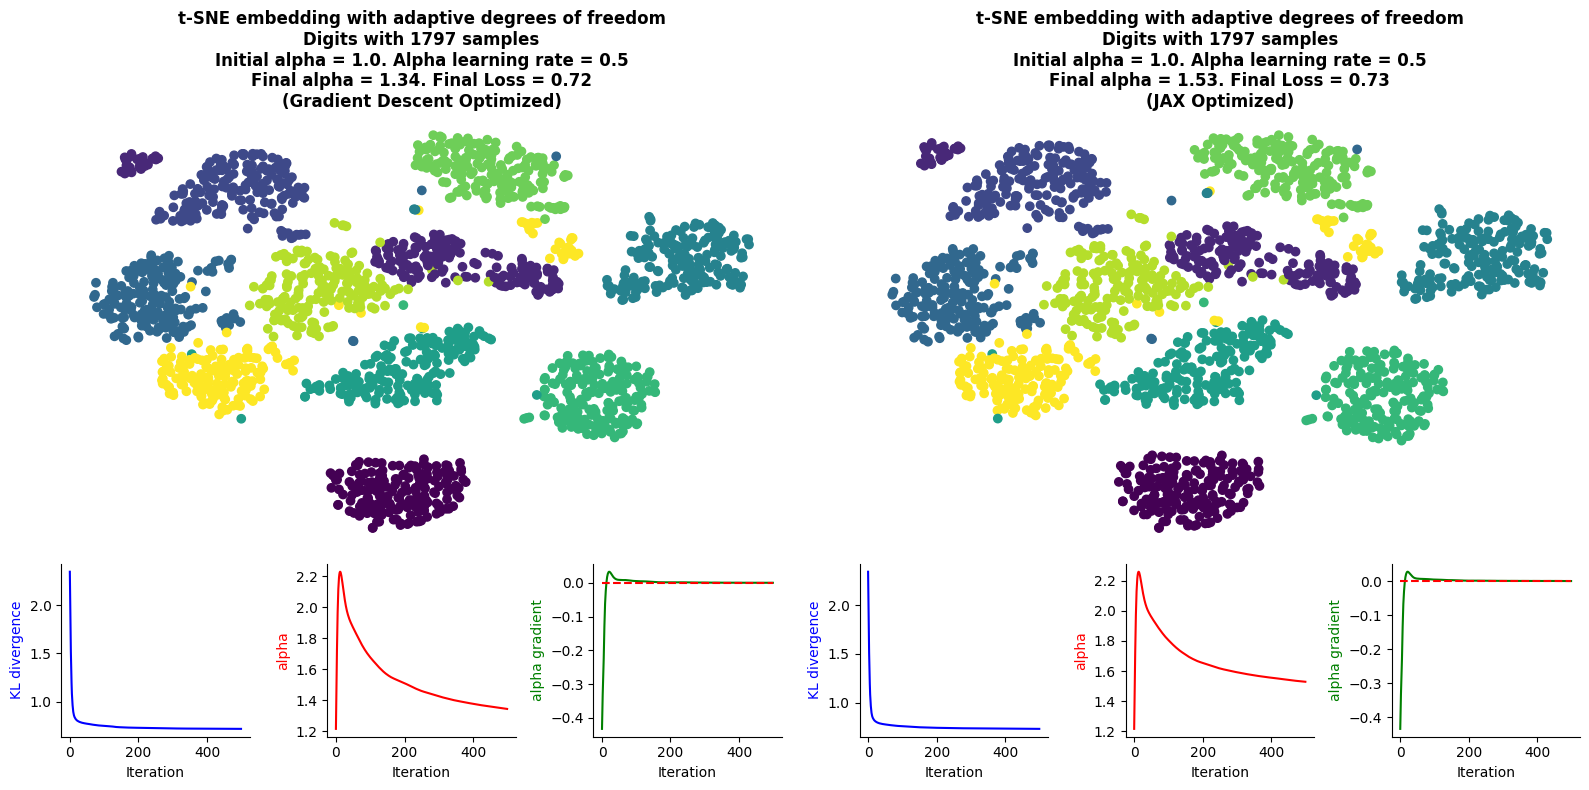

In [49]:
tsne_result_digits_1_jax = utils.tsne_with_dof_optimisation(X=X, n_iter=500, initial_alpha=test_alpha, dataset_name="Digits", verbose=True, optimise_for_alpha="jax", alpha_lr=0.5)
utils.plot_side_by_side(tsne_result_digits_1_gd, tsne_result_digits_1_jax, color, additional_title_1="(Gradient Descent Optimized)", additional_title_2="(JAX Optimized)")